In [ ]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import copy, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import cfgrib
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xarray as xr
import glob
import pandas as pd

In [ ]:
# ── CONSTANTS ─────────────────────────────────────────────────────────────────
path = 'C:\\Users\\maili\\Desktop\\KU\\AppMachineLearning\\Final_Project\\data\\'
MODEL_PATH    = 'saved_models/best_precip_model_2015_2026.pt'
LAG           = 24
HORIZON       = 24
FINAL_EPOCHS  = 10
BATCH         = 128
RAIN_THRESHOLD = 0.01  # mm/hr, adjust based on data distribution
TARGET_HOUR = 17
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
 # delete all corrupted index files
idx_files = glob.glob(path + "*.idx")
for f in idx_files:
   os.remove(f)
   print(f"Deleted: {f}")

Deleted: C:\Users\maili\Desktop\KU\AppMachineLearning\Final_Project\data\grid-timeseries_sel_vars_1940.grib.5b7b6.idx
Deleted: C:\Users\maili\Desktop\KU\AppMachineLearning\Final_Project\data\grid-timeseries_sel_vars_2015.grib.5b7b6.idx


In [ ]:
filenames = [
    "grid-timeseries_sel_vars_2015.grib", "grid-timeseries_sel_vars_2016.grib",
    "grid-timeseries_sel_vars_2017.grib", "grid-timeseries_sel_vars_2018.grib",
    "grid-timeseries_sel_vars_2019.grib", "grid-timeseries_sel_vars_2020.grib",
    "grid-timeseries_sel_vars_2021.grib", "grid-timeseries_sel_vars_2022.grib",
    "grid-timeseries_sel_vars_2023.grib", "grid-timeseries_sel_vars_2024.grib",
    "grid-timeseries_sel_vars_2025.grib", "grid-timeseries_sel_vars_2026_april.grib"
]

all_ds0, all_ds1 = [], []

for fname in filenames:
    fpath = path + fname
    print(f"Opening {fname}...")
    datasets = cfgrib.open_datasets(fpath)

    ds0 = next((d for d in datasets if 'sp' in d.data_vars), None)
    ds1 = next((d for d in datasets if 'tp' in d.data_vars), None)

    if ds0 is None or ds1 is None:
        print(f"  ✗ missing ds0 or ds1 in {fname}")
        continue

    all_ds0.append(ds0)
    all_ds1.append(ds1)
    print(f"  ✓ ds0 vars: {list(ds0.data_vars)} | ds1 vars: {list(ds1.data_vars)}")

# concatenate across years
ds0 = xr.concat(all_ds0, dim="time", compat = "override", coords="minimal")
ds1 = xr.concat(all_ds1, dim="time", compat = "override", coords="minimal")

# match original variable names
ref_lat  = ds0.latitude.values
ref_lon  = ds0.longitude.values
ref_time = ds0.time

print("\nds0:", ds0)
print("\nds1:", ds1)
print("\nTime range:", ref_time.values[0], "→", ref_time.values[-1])
print("Total timesteps:", len(ref_time))


Opening grid-timeseries_sel_vars_2015.grib...


c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili

  ✓ ds0 vars: ['sp', 'tcc', 'u10', 'v10', 't2m'] | ds1 vars: ['ssrd', 'tp']
Opening grid-timeseries_sel_vars_2016.grib...


c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili

  ✓ ds0 vars: ['sp', 'tcc', 'u10', 'v10', 't2m'] | ds1 vars: ['ssrd', 'tp']
Opening grid-timeseries_sel_vars_2017.grib...


...

  ✓ ds0 vars: ['sp', 'tcc', 'u10', 'v10', 't2m'] | ds1 vars: ['ssrd', 'tp']
Opening grid-timeseries_sel_vars_2025.grib...


c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili

  ✓ ds0 vars: ['sp', 'tcc', 'u10', 'v10', 't2m'] | ds1 vars: ['ssrd', 'tp']
Opening grid-timeseries_sel_vars_2026_april.grib...


c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili

  ✓ ds0 vars: ['sp', 'tcc', 'u10', 'v10', 't2m'] | ds1 vars: ['ssrd', 'tp']

ds0: <xarray.Dataset> Size: 50MB
Dimensions:     (time: 96624, latitude: 5, longitude: 5)
Coordinates:
  * time        (time) datetime64[ns] 773kB 2015-01-01 ... 2026-04-16T23:00:00
    valid_time  (time) datetime64[ns] 773kB 2015-01-01 ... 2026-04-16T23:00:00
  * latitude    (latitude) float64 40B 56.0 55.75 55.5 55.25 55.0
  * longitude   (longitude) float64 40B 12.0 12.25 12.5 12.75 13.0
    number      int64 8B 0
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
Data variables:
    sp          (time, latitude, longitude) float32 10MB 1.026e+05 ... 1.023e+05
    tcc         (time, latitude, longitude) float32 10MB 0.896 0.9568 ... 0.1006
    u10         (time, latitude, longitude) float32 10MB 7.11 6.43 ... -0.6145
    v10         (time, latitude, longitude) float32 10MB 1.532 1.116 ... 1.252
    t2m         (time, latitude, longitude) float32 10MB 277.8 277.7 ... 278.3
Attributes:


In [17]:
# save ds0 and ds1 to netCDF for easier loading later
ds0.to_netcdf("data/ds0_all_years.nc")
ds1.to_netcdf("data/ds1_all_years.nc")

In [ ]:
# datasets = cfgrib.open_datasets("C:\\Users\\maili\\Desktop\\KU\\AppMachineLearning\\Final_Project\\data\\grid-timeseries_sel_vars_1940.grib")
# ds0, ds1 = datasets

# ref_lat  = ds0.latitude
# ref_lon  = ds0.longitude
# ref_time = ds0.time

# channels, chan_names = [], []

# for var in ['sp', 'tcc', 'u10', 'v10', 't2m']:
#     channels.append(ds0[var].values.astype(np.float32))
#     chan_names.append(var)


c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili

In [ ]:
# flatten (time, step) → valid_time for tp and ssrd
tp_flat   = ds1["tp"].stack(alltime=("time", "step"))    # (8064*12, 5, 5)
ssrd_flat = ds1["ssrd"].stack(alltime=("time", "step"))

# valid_time is the actual timestamp each forecast is valid at
vt = tp_flat.valid_time.values  # shape (96768,)

print("tp_flat shape:", tp_flat.shape)
print("valid_time range:", vt[0], "→", vt[-1])
print("total:", len(vt))

# build a lookup from valid_time → tp value
vt_index = pd.DatetimeIndex(vt)
ds0_index = pd.DatetimeIndex(ds0.time.values)

# find which valid_times exist in ds0
common = vt_index.intersection(ds0_index)
print("Overlapping timesteps:", len(common))


tp_flat shape: (5, 5, 96768)
valid_time range: 2014-12-31T19:00:00.000000000 → 2026-04-17T06:00:00.000000000
total: 96768
Overlapping timesteps: 96624


In [ ]:
# sort by valid_time
sort_idx    = np.argsort(vt_index)
vt_sorted   = vt_index[sort_idx]
tp_sorted   = tp_flat_np[sort_idx]
ssrd_sorted = ssrd_flat_np[sort_idx]

# keep only first occurrence of each timestamp
_, first_occ = np.unique(vt_sorted, return_index=True)
vt_unique   = vt_sorted[first_occ]
tp_unique   = tp_sorted[first_occ]
ssrd_unique = ssrd_sorted[first_occ]

print("Unique valid_times:", len(vt_unique))

# now align with ds0
ds0_index = pd.DatetimeIndex(ds0.time.values)
vt_unique_idx = pd.DatetimeIndex(vt_unique)
loc = vt_unique_idx.get_indexer(ds0_index)

print("Unmatched ds0 times:", (loc == -1).sum())  # should be 0

valid = loc != -1
tp_aligned   = tp_unique[loc[valid]]
ssrd_aligned = ssrd_unique[loc[valid]]
ds0_time     = ds0.time.values[valid]

print("tp_aligned:", tp_aligned.shape)
print("ssrd_aligned:", ssrd_aligned.shape)

# build channels
T = len(ds0_time) - 1
tp_target = tp_aligned[1:].astype(np.float32)

channels, chan_names = [], []
for var in ['sp', 'tcc', 'u10', 'v10', 't2m']:
    channels.append(ds0[var].values[valid][:T].astype(np.float32))
    chan_names.append(var)

channels.append(tp_aligned[:T].astype(np.float32))
chan_names.append("tp")
channels.append(ssrd_aligned[:T].astype(np.float32))
chan_names.append("ssrd")

ref_time = ds0_time[:T]

print("\nTarget shape:", tp_target.shape)
for name, ch in zip(chan_names, channels):
    print(f"  {name}: {ch.shape}")
print("Time range:", ref_time[0], "→", ref_time[-1])

Unique valid_times: 96648
Unmatched ds0 times: 0
tp_aligned: (96624, 5, 5)
ssrd_aligned: (96624, 5, 5)

Target shape: (96623, 5, 5)
  sp: (96623, 5, 5)
  tcc: (96623, 5, 5)
  u10: (96623, 5, 5)
  v10: (96623, 5, 5)
  t2m: (96623, 5, 5)
  tp: (96623, 5, 5)
  ssrd: (96623, 5, 5)
Time range: 2015-01-01T00:00:00.000000000 → 2026-04-16T22:00:00.000000000


In [ ]:
for var in ['ssrd', 'tp']:
    # find which dataset contains this variable
    ds_acc = None
    for ds in datasets:
        if var in ds.data_vars:
            ds_acc = ds
            break
    if ds_acc is None:
        print(f"WARNING: {var} not found in any dataset!")
        continue

    arr = ds_acc[var]  # shape: (time, step, lat, lon)
    print(f"{var} dims: {arr.dims}, shape: {arr.shape}")
    
    # deaccumulate along step, then take the last step (= 12h total)
    # or sum the diffs to get total over all steps
    arr_deacc = arr.diff(dim='step')          # per-hour amounts
    arr_total = arr.isel(step=-1)             # last step = total accumulated over 12h

    arr_daily = xr.DataArray(
        arr_total.values.astype(np.float32),
        coords={'time': ds_acc[var].time.values,
                'latitude': ref_lat,
                'longitude': ref_lon},
        dims=['time', 'latitude', 'longitude']
    )
    arr_h = arr_daily.reindex(time=ref_time, method='ffill').ffill(dim='time').bfill(dim='time')
    channels.append(arr_h.values.astype(np.float32))
    chan_names.append(var)

ssrd dims: ('time', 'step', 'latitude', 'longitude'), shape: (732, 12, 5, 5)
tp dims: ('time', 'step', 'latitude', 'longitude'), shape: (732, 12, 5, 5)


In [ ]:
X_raw = np.stack(channels, axis=1).astype(np.float32)
tp_idx = chan_names.index('tp')

y_raw = channels[tp_idx].copy()

# clean NaNs
#for i in range(X_raw.shape[1]):
   # m = np.nanmean(X_raw[:, i])
    #X_raw[:, i] = np.nan_to_num(X_raw[:, i], nan=m)
#y_raw = np.nan_to_num(y_raw, nan=np.nanmean(y_raw))

# log transform
y_raw = np.log1p(y_raw * 1000)
X_raw[:, tp_idx] = np.log1p(X_raw[:, tp_idx] * 1000)

N = X_raw.shape[0]
N_FEATURES = X_raw.shape[1]


In [ ]:
# ── 4. WINDOWS ────────────────────────────────────────────────────────────────
def make_windows(X, y, lag=LAG, horizon=HORIZON):
    idx = np.arange(lag, len(X) - horizon)
    Xw = np.stack([X[i-lag:i] for i in idx]).astype(np.float32)
    yw = np.stack([y[i+horizon] for i in idx]).astype(np.float32)
    return Xw, yw


X_all_w, y_all = make_windows(X_raw, y_raw)

train_end_w = int(0.70 * len(X_all_w))
val_end_w   = int(0.85 * len(X_all_w))

X_train_w, y_train = X_all_w[:train_end_w],          y_all[:train_end_w]
X_val_w,   y_val   = X_all_w[train_end_w:val_end_w], y_all[train_end_w:val_end_w]
X_test_w,  y_test  = X_all_w[val_end_w:],            y_all[val_end_w:]

In [ ]:
def fit_scale(Xw):
    # Xw shape: (N, lag, C, H, W)
    # compute mean/std per channel, over N, lag, H, W
    mean = Xw.mean(axis=(0, 1, 3, 4))  # shape: (C,)
    std  = Xw.std(axis=(0, 1, 3, 4)) + 1e-8  # shape: (C,)
    return mean, std

def transform(Xw, sc):
    m, s = sc
    # broadcast (C,) over (N, lag, C, H, W)
    return ((Xw - m[None, None, :, None, None]) / 
             s[None, None, :, None, None]).astype(np.float32)

scaler = fit_scale(X_train_w)
X_tr_sc = transform(X_train_w, scaler)
X_te_sc = transform(X_test_w, scaler)
X_va_sc = transform(X_val_w, scaler)
y_tr, y_te, y_va = y_train, y_test, y_val


In [ ]:
# ── 6. DATASET ────────────────────────────────────────────────────────────────
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

def loader(X, y, shuffle):
    return DataLoader(SeqDS(X, y), batch_size=BATCH, shuffle=shuffle)

# ── 7. MODEL ──────────────────────────────────────────────────────────────────
class ConvLSTMModel(nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.2):
        super().__init__()
        self.hidden = hidden
        self.cell = ConvLSTMCell(in_ch, hidden)
        self.norm = nn.GroupNorm(8, hidden)
        self.drop = nn.Dropout2d(dropout)

        # shared backbone
        self.backbone = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(hidden, hidden // 2, 3, padding=1),
            nn.ReLU(),
        )
        # probability head → sigmoid output (0-1)
        self.prob_head   = nn.Conv2d(hidden // 2, 1, 1)
        # amount head → raw output (we'll expm1 later)
        self.amount_head = nn.Conv2d(hidden // 2, 1, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        h = torch.zeros(B, self.hidden, H, W, device=x.device)
        c = torch.zeros(B, self.hidden, H, W, device=x.device)
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
        h = self.norm(h)
        h = self.drop(h)
        feat = self.backbone(h)

        prob   = torch.sigmoid(self.prob_head(feat)).squeeze(1)   # (B, H, W) 0-1
        amount = self.amount_head(feat).squeeze(1)                # (B, H, W) raw
        return prob, amount

In [ ]:
# ── LOSS ──────────────────────────────────────────────────────────────────────
def rain_loss(prob, amount, target):
    rain_mask = (target > 0.01).float()

    # BCE for probability
    bce = nn.functional.binary_cross_entropy(prob, rain_mask)

    # MSE/MAE only on rainy pixels for amount
    weight = 1.0 + 20.0 * rain_mask
    mse = (weight * (amount - target) ** 2).mean()
    mae = (weight * torch.abs(amount - target)).mean()
    amount_loss = 0.7 * mse + 0.3 * mae

    return bce + amount_loss, bce, amount_loss  # return components for logging

In [ ]:

# ── 8. HYPERPARAM SEARCH ──────────────────────────────────────────────────────
def train_and_eval(hidden, lr):
    model = ConvLSTMModel(N_FEATURES, hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    tr_loader = loader(X_tr_sc, y_tr, True)
    va_loader = loader(X_va_sc, y_va, False)

    best_val = float("inf")

    for _ in range(6):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)

            opt.zero_grad()
            loss = rain_loss(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        vals = []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                vals.append(rain_loss(model(xb), yb).item())

        best_val = min(best_val, np.mean(vals))

    return best_val

param_grid = {
    "hidden": [32, 64, 128],
    "lr": [1e-3, 3e-4, 1e-4],
}

best_score = float("inf")
best_params = None

for h in param_grid["hidden"]:
    for lr in param_grid["lr"]:
        score = train_and_eval(h, lr)

        print(f"h={h}, lr={lr} → {score:.5f}")

        if score < best_score:
            best_score = score
            best_params = (h, lr)

print("\nBEST:", best_params)



NameError: name 'ConvLSTMCell' is not defined

In [ ]:
import optuna
import numpy as np
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Small subset for speed ─────────────────────────────────────────────────────
n = int(0.2 * len(X_tr_sc)) # increase probably
X_tr_small = X_tr_sc[:n]
y_tr_small = y_tr[:n]

# ── Objective ─────────────────────────────────────────────────────────────────
def objective(trial):
    hidden  = trial.suggest_categorical("hidden", [64, 128])
    lr      = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.4)

    model = ConvLSTMModel(N_FEATURES, hidden, dropout).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)

    tr_loader = loader(X_tr_small, y_tr_small, True)
    va_loader = loader(X_va_sc, y_va, False)

    best_val = float("inf")
    patience, no_imp = 3, 0

    for epoch in range(8):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            rain_loss(model(xb), yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            val = np.mean([
                rain_loss(model(xb.to(device)), yb.to(device)).item()
                for xb, yb in va_loader
            ])

        if val < best_val:
            best_val = val
            no_imp = 0
        else:
            no_imp += 1

        trial.report(val, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if no_imp >= patience:
            break

    return best_val

# ── Run study ─────────────────────────────────────────────────────────────────
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3)
)
study.optimize(objective, n_trials=3, show_progress_bar=True)

# ── Results ───────────────────────────────────────────────────────────────────
best_hidden  = study.best_params["hidden"]
best_lr      = study.best_params["lr"]
best_dropout = study.best_params["dropout"]

print(f"\nBest params:  hidden={best_hidden}, lr={best_lr:.6f}, dropout={best_dropout:.3f}")
print(f"Best val loss: {study.best_value:.5f}")


'''

Best params:  hidden=64, lr=0.000819, dropout=0.231
Best val loss: 0.17577'''

  0%|          | 0/3 [00:00<?, ?it/s]

[W 2026-06-03 16:19:03,462] Trial 0 failed with parameters: {'hidden': 128, 'lr': 0.00028457293861885606, 'dropout': 0.2021342971280296} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\maili\AppData\Local\Temp\ipykernel_35504\1565760420.py", line 30, in objective
    rain_loss(model(xb), yb).backward()
  File "c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\torch\_tensor.py", line 631, in backward
    torch.autograd.backward(
  File "c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\torch\autograd\__init__.py", line 379, in backward
    _engine_run_backward(
  File "c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\torch\autograd\graph.py", line 882, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # C

KeyboardInterrupt: 

In [ ]:
best_hidden = 128
best_lr = 1e-3
best_dropout = 0.1

model = ConvLSTMModel(N_FEATURES, best_hidden, best_dropout).to(device)
opt       = torch.optim.Adam(model.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
tr_loader = loader(X_tr_sc, y_tr, True)
va_loader = loader(X_va_sc, y_va, False)


best_val = float("inf")
best_state = copy.deepcopy(model.state_dict())
train_losses, val_losses = [], []

# ── early stopping params
PATIENCE = 2
patience_counter = 0

for epoch in range(FINAL_EPOCHS):
    model.train()
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        prob, amount = model(xb)
        loss, bce, amt_loss = rain_loss(prob, amount, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    model.eval()
    vl = []
    with torch.no_grad():
        prob, amount = model(x_input)
        for xb, yb in va_loader:
            xb, yb = xb.to(device), yb.to(device)
            vl.append(rain_loss(model(xb), yb).item())
    val = np.mean(vl)
    val_losses.append(val)
    prob_pct   = prob * 100                    # e.g. 73% chance of rain
    amount_mm  = np.expm1(amount.cpu().numpy()) / 1000   # back to mm
    print(f"Epoch {epoch+1}: train={train_losses[-1]:.5f}, val={val:.5f}")

    if val < best_val:
        best_val = val
        best_state = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_PATH)
        patience_counter = 0  # reset on improvement
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
model.load_state_dict(best_state)

Epoch 1: train=0.35518, val=0.31569
Epoch 2: train=0.23458, val=0.26120
Epoch 3: train=0.20007, val=0.28551
  No improvement (1/2)


KeyboardInterrupt: 

In [ ]:
model.load_state_dict(best_state)
print(f"Loaded best model with val loss: {best_val:.5f}")

Loaded best model with val loss: 0.26120


           TEST SET METRICS
  MAE          : 0.1146 mm
  RMSE         : 0.2659 mm
  Bias         : -0.0063 mm
  Correlation  : 0.0453
---------------------------------------------
  POD (recall) : 0.2199  (fraction of rain events caught)
  FAR          : 0.8493  (fraction of rain alarms that are false)
  CSI          : 0.0982  (overall skill, 1=perfect)


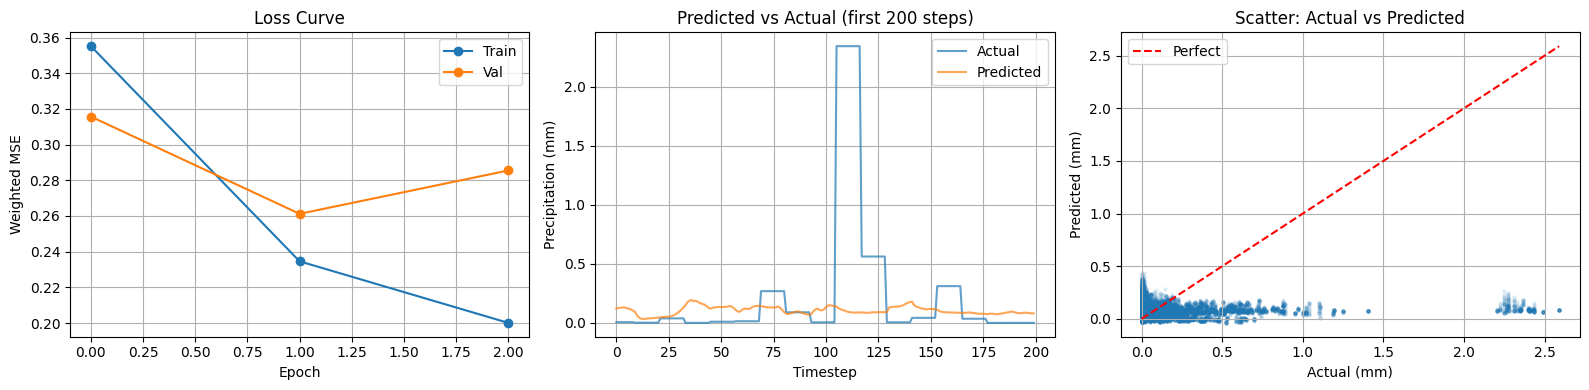

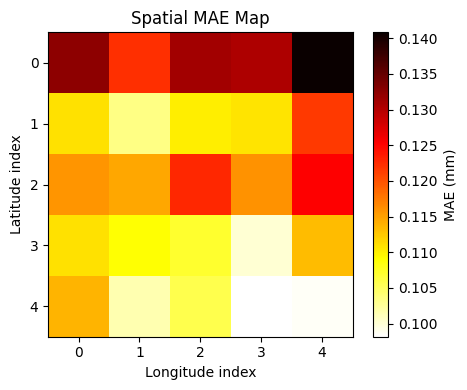

: 

In [ ]:
# ── EVALUATION ────────────────────────────────────────────────────────────────
model.eval()
# ── collect predictions on test set
all_preds, all_targets = [], []
te_loader = loader(X_te_sc, y_te, shuffle=False)

with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()  # (B, H, W)
        all_preds.append(pred)
        all_targets.append(yb.numpy())

preds   = np.concatenate(all_preds,   axis=0)  # (N, 5, 5)
targets = np.concatenate(all_targets, axis=0)  # (N, 5, 5)

# ── inverse log transform → back to mm
preds_mm   = np.expm1(preds)   / 1000
targets_mm = np.expm1(targets) / 1000

# ── flatten spatial for scalar metrics
preds_flat   = preds_mm.reshape(-1)
targets_flat = targets_mm.reshape(-1)

# ── 1. SCALAR METRICS ─────────────────────────────────────────────────────────
mae  = mean_absolute_error(targets_flat, preds_flat)
rmse = np.sqrt(mean_squared_error(targets_flat, preds_flat))
bias = (preds_flat - targets_flat).mean()

# correlation
corr = np.corrcoef(targets_flat, preds_flat)[0, 1]

# skill scores for rain detection (binary)
threshold = 0.1 / 1000  # 0.1 mm threshold for "rain event"
pred_rain   = preds_flat   > threshold
target_rain = targets_flat > threshold

hits        = (pred_rain  & target_rain).sum()
misses      = (~pred_rain & target_rain).sum()
false_alarm = (pred_rain  & ~target_rain).sum()
correct_neg = (~pred_rain & ~target_rain).sum()

pod  = hits / (hits + misses + 1e-8)          # probability of detection
far  = false_alarm / (hits + false_alarm + 1e-8)  # false alarm ratio
csi  = hits / (hits + misses + false_alarm + 1e-8)  # critical success index

print("=" * 45)
print("           TEST SET METRICS")
print("=" * 45)
print(f"  MAE          : {mae*1000:.4f} mm")
print(f"  RMSE         : {rmse*1000:.4f} mm")
print(f"  Bias         : {bias*1000:.4f} mm")
print(f"  Correlation  : {corr:.4f}")
print("-" * 45)
print(f"  POD (recall) : {pod:.4f}  (fraction of rain events caught)")
print(f"  FAR          : {far:.4f}  (fraction of rain alarms that are false)")
print(f"  CSI          : {csi:.4f}  (overall skill, 1=perfect)")
print("=" * 45)

# ── 2. TRAINING CURVE ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_losses, label='Train', marker='o')
axes[0].plot(val_losses,   label='Val',   marker='o')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE')
axes[0].legend()
axes[0].grid(True)

# ── 3. PREDICTED VS ACTUAL (spatial mean over grid) ───────────────────────────
pred_ts   = preds_mm.mean(axis=(1,2))    * 1000  # mean over 5×5 grid → mm
target_ts = targets_mm.mean(axis=(1,2)) * 1000

axes[1].plot(target_ts[:200], label='Actual',    alpha=0.7)
axes[1].plot(pred_ts[:200],   label='Predicted', alpha=0.7)
axes[1].set_title('Predicted vs Actual (first 200 steps)')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()
axes[1].grid(True)

# ── 4. SCATTER PLOT ───────────────────────────────────────────────────────────
axes[2].scatter(targets_flat * 1000, preds_flat * 1000, alpha=0.1, s=5)
axes[2].plot([0, targets_flat.max()*1000],
             [0, targets_flat.max()*1000], 'r--', label='Perfect')
axes[2].set_title('Scatter: Actual vs Predicted')
axes[2].set_xlabel('Actual (mm)')
axes[2].set_ylabel('Predicted (mm)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150)
plt.show()

# ── 5. SPATIAL ERROR MAP ──────────────────────────────────────────────────────
mae_map = np.abs(preds_mm - targets_mm).mean(axis=0) * 1000  # (5, 5) in mm

fig2, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(mae_map, cmap='hot_r')
plt.colorbar(im, ax=ax, label='MAE (mm)')
ax.set_title('Spatial MAE Map')
ax.set_xlabel('Longitude index')
ax.set_ylabel('Latitude index')
plt.tight_layout()
plt.savefig('spatial_mae.png', dpi=150)
plt.show()